In [15]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from src.features.build_features import basic_feature_engineering
from src.features.pipeline import build_preprocessing_pipeline
from src.models.train import train_logistic_model


In [16]:
df = pd.read_csv("../data/raw/home_credit/application_train.csv")

df_fe = basic_feature_engineering(df)


In [17]:
X = df_fe.drop(columns=["TARGET"])
y = df_fe["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [18]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

preprocessor = build_preprocessing_pipeline(num_cols, cat_cols)


In [19]:
log_model = train_logistic_model(preprocessor, X_train, y_train)

log_preds = log_model.predict_proba(X_val)[:,1]

print("Logistic ROC AUC:", roc_auc_score(y_val, log_preds))


Logistic ROC AUC: 0.7490910033968367


In [20]:
from src.models.train_tree import train_random_forest
rf_model = train_random_forest(preprocessor, X_train, y_train)
rf_pred = rf_model.predict_proba(X_val)[:,1]
print("RF Validation ROC AUC:", roc_auc_score(y_val, rf_pred))



RF Validation ROC AUC: 0.7264878772013241


In [21]:
from src.models.train_gb import train_gb

gb_model = train_gb(preprocessor, X_train, y_train)

gb_preds = gb_model.predict_proba(X_val)[:,1]

print("GB Validation ROC AUC:", roc_auc_score(y_val, gb_preds))


GB Validation ROC AUC: 0.7531029563233982


In [22]:
from src.models.evaluate import evaluate_model_cv

cv_results = evaluate_model_cv(log_model,X,y,cv=5)
print(cv_results)

{'mean_auc': 0.7464918137591644, 'std_auc': 0.0026011922570842896, 'all_scores': array([0.74632034, 0.74543494, 0.74233548, 0.74850882, 0.74985948])}


In [23]:
rf = rf_model.named_steps["model"]
importances = rf.feature_importances_


In [24]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()


In [25]:
import pandas as pd

feat_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_importance_df.head(20)


,feature,importance
29,num__EXT_SOURCE_2,0.055120
30,num__EXT_SOURCE_3,0.052890
10,num__DAYS_ID_PUBLISH,0.030623
105,num__AGE_YEARS,0.030067
7,num__DAYS_BIRTH,0.029986
9,num__DAYS_REGISTRATION,0.029853
8,num__DAYS_EMPLOYED,0.029486
107,num__ANNUITY_TO_INCOME,0.028516
0,num__SK_ID_CURR,0.028306
106,num__CREDIT_TO_INCOME,0.027339


- feature importances dominated by EXT_SOURCE (external credit risk proxies) & self engineered features (ratios) which is a good sign

- num__SK_ID_CURR should not be present, (id should not be predictive measure) and must be dropped

- AGE_YEARS and DAYS_BIRTH both are present, DAYS_BIRTH should be dropped

In [26]:
from src.models.train_histgb import train_hist_gradient_boosting

histgb_model = train_hist_gradient_boosting(preprocessor, X_train, y_train)
histgb_preds = histgb_model.predict_proba(X_val)[:,1]
print("HistGB Validation ROC AUC: ",roc_auc_score(y_val,histgb_preds))


HistGB Validation ROC AUC:  0.7587044754934404


not a big jump, needs tuning

In [27]:
histgb_model = train_hist_gradient_boosting(preprocessor, X_train, y_train)

histgb_preds = histgb_model.predict_proba(X_val)[:,1]

print("Tuned HistGB ROC AUC:", roc_auc_score(y_val, histgb_preds))


Tuned HistGB ROC AUC: 0.7587044754934404


In [29]:
# Install xgboost into the notebook kernel's environment (run once)
%pip install xgboost -q

Note: you may need to restart the kernel to use updated packages.


- produced exact same AUC score after tuning 
- model has plataeued

In [30]:
from src.models.train_xgb import train_xgb

xgb_model = train_xgb(preprocessor,X_train,y_train)
xgb_preds = xgb_model.predict_proba(X_val)[:,1]

print("XGBoost Validation ROC AUC:", roc_auc_score(y_val, xgb_preds))



XGBoost Validation ROC AUC: 0.7621712737686926


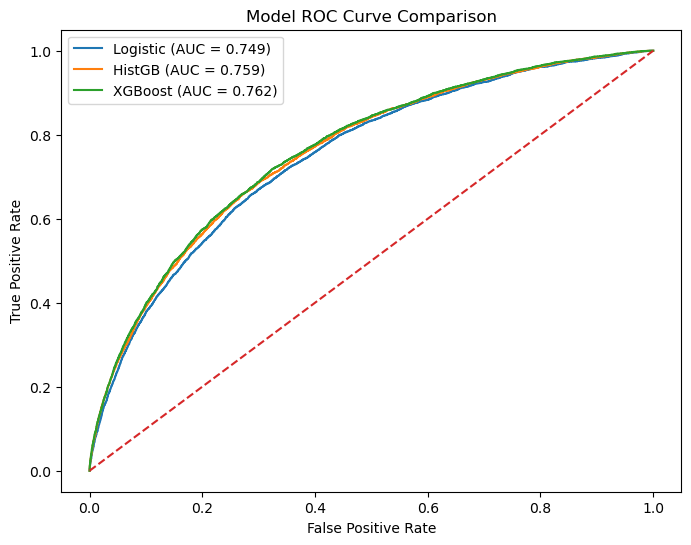

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


fpr_log, tpr_log, _ = roc_curve(y_val, log_preds)
fpr_hist, tpr_hist, _ = roc_curve(y_val, histgb_preds)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_preds)

auc_log = auc(fpr_log, tpr_log)
auc_hist = auc(fpr_hist, tpr_hist)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_hist, tpr_hist, label=f"HistGB (AUC = {auc_hist:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model ROC Curve Comparison")
plt.legend()
plt.show()


In [33]:


model_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "HistGradientBoosting", "XGBoost"],
    "Validation ROC AUC": [auc_log, auc_hist, auc_xgb]
})

model_summary.sort_values("Validation ROC AUC", ascending=False)


,Model,Validation ROC AUC
2,XGBoost,0.762171
1,HistGradientBoosting,0.758704
0,Logistic Regression,0.749091


In [34]:
from src.models.save_model import save_model

model_path = save_model(xgb_model)

print("Model saved at:", model_path)


Model saved at: artifacts/xgb_credit_model.joblib


In [35]:
import joblib

loaded_model = joblib.load(model_path)

test_preds = loaded_model.predict_proba(X_val[:5])[:,1]

print(test_preds)



[0.05251757 0.03979519 0.287614   0.0624204  0.09695483]


In [36]:
xgb = xgb_model.named_steps["model"]

importances = xgb.feature_importances_

feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()


In [37]:


feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)


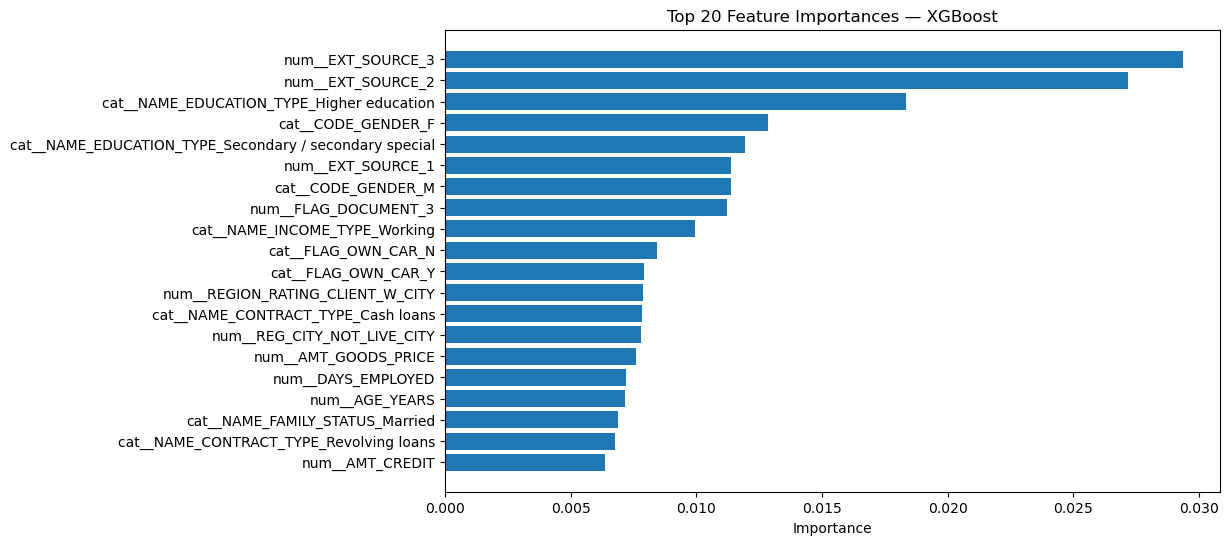

In [38]:
import matplotlib.pyplot as plt

top_n = 20

plt.figure(figsize=(10,6))

plt.barh(
    feat_imp_df.head(top_n)["feature"][::-1],
    feat_imp_df.head(top_n)["importance"][::-1]
)

plt.title("Top 20 Feature Importances — XGBoost")
plt.xlabel("Importance")
plt.show()
